In [ ]:
# ── Rebuild processed data from scratch ──────────────────────────────────────
from google.colab import files
files.upload()  # upload kaggle.json

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d epicskills/tox21-dataset --unzip -p /content/tox21/ -q
!kaggle datasets download -d basu369victor/zinc250k --unzip -p /content/zinc250k/ -q

!pip install rdkit deepchem imbalanced-learn -q

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, QED
from rdkit.Chem.inchi import MolToInchiKey

tox21_df = pd.read_csv('/content/tox21/tox21.csv')
zinc_df  = pd.read_csv('/content/zinc250k/250k_rndm_zinc_drugs_clean_3.csv')
zinc_df['smiles'] = zinc_df['smiles'].str.strip()

def is_valid_smiles(smi):
    try: return Chem.MolFromSmiles(str(smi)) is not None
    except: return False

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return [np.nan] * 8
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol), rdMolDescriptors.CalcNumRings(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol), Descriptors.FractionCSP3(mol)]

def get_inchikey(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        return MolToInchiKey(mol) if mol else None
    except: return None

def smiles_to_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return np.zeros(n_bits)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))

tox21_df = tox21_df[tox21_df['smiles'].apply(is_valid_smiles)].reset_index(drop=True)

desc_cols = ['MolWt','LogP','HBD','HBA','TPSA','NumRings','AromaticRings','FractionCSP3']
desc_df   = pd.DataFrame(tox21_df['smiles'].apply(compute_descriptors).tolist(), columns=desc_cols)
tox21_df  = pd.concat([tox21_df, desc_df], axis=1)

tox21_df['inchikey'] = tox21_df['smiles'].apply(get_inchikey)
zinc_df['inchikey']  = zinc_df['smiles'].apply(get_inchikey)
zinc_features        = zinc_df[['inchikey','logP','qed','SAS']].dropna(subset=['inchikey'])
tox21_df             = tox21_df.merge(zinc_features, on='inchikey', how='left')

mask = tox21_df['qed'].isna()
tox21_df.loc[mask, 'logP'] = tox21_df.loc[mask, 'smiles'].apply(
    lambda s: Descriptors.MolLogP(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else np.nan)
tox21_df.loc[mask, 'qed']  = tox21_df.loc[mask, 'smiles'].apply(
    lambda s: QED.qed(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else np.nan)

fp_matrix = np.vstack(tox21_df['smiles'].apply(smiles_to_fp).values)

os.makedirs('/content/processed', exist_ok=True)
tox21_df.to_csv('/content/processed/tox21_processed.csv', index=False)
np.save('/content/processed/fp_matrix.npy', fp_matrix)

print(f"Ready. Compounds: {len(tox21_df)} | FP shape: {fp_matrix.shape}")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/epicskills/tox21-dataset
License(s): DbCL-1.0
Dataset URL: https://www.kaggle.com/datasets/basu369victor/zinc250k
License(s): DbCL-1.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 32.7 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:30:18] DEPRECATION WARNING: please use MorganGenerator
[14:3

Ready. Compounds: 7823 | FP shape: (7823, 2048)


In [ ]:
# ToxLens | 02 — XGBoost Baseline
### Multi-task toxicity prediction across 12 Tox21 assays
### Features: ECFP4 Morgan fingerprints + RDKit descriptors + QED

In [ ]:
#Cell — Installs
!pip install xgboost optuna mlflow shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.7 MB/s eta 0:00:00


In [ ]:
#Cell — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.sklearn
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
import pickle

sns.set_theme(style="whitegrid", palette="muted")
print("All imports successful.")

All imports successful.


In [ ]:
#Cell — Load processed data
tox21_df = pd.read_csv('/content/processed/tox21_processed.csv')
fp_matrix = np.load('/content/processed/fp_matrix.npy')

assay_cols = ['NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase',
              'NR-ER','NR-ER-LBD','NR-PPAR-gamma',
              'SR-ARE','SR-ATAD5','SR-HSE','SR-MMP','SR-p53']

# Drop redundant logP, keep RDKit LogP
desc_cols = ['MolWt','LogP','HBD','HBA','TPSA','NumRings','AromaticRings','FractionCSP3','qed']

print(f"Loaded: {len(tox21_df)} compounds")
print(f"Descriptor features: {desc_cols}")

Loaded: 7823 compounds
Descriptor features: ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA', 'NumRings', 'AromaticRings', 'FractionCSP3', 'qed']


In [ ]:
#Cell — Build feature matrix
# Combine fingerprints + descriptors
desc_matrix = tox21_df[desc_cols].fillna(tox21_df[desc_cols].median()).values
X = np.hstack([fp_matrix, desc_matrix])

print(f"Full feature matrix shape: {X.shape}")
print(f"  Morgan FP:   {fp_matrix.shape[1]} bits")
print(f"  Descriptors: {desc_matrix.shape[1]} features")
print(f"  Total:       {X.shape[1]} features")

Full feature matrix shape: (7823, 2057)
  Morgan FP:   2048 bits
  Descriptors: 9 features
  Total:       2057 features


In [ ]:
#Cell — Optuna + XGBoost training loop
mlflow.set_experiment("ToxLens_XGBoost_Baseline")

results = {}
models  = {}

for assay in assay_cols:
    # Get labeled rows only
    mask   = tox21_df[assay].notna()
    X_task = X[mask]
    y_task = tox21_df.loc[mask, assay].astype(int).values

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X_task, y_task, test_size=0.2, random_state=42, stratify=y_task
    )

    # Class imbalance weight
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos if pos > 0 else 1.0

    # Optuna objective
    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 100, 400),
            'max_depth':         trial.suggest_int('max_depth', 3, 8),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'scale_pos_weight':  spw,
            'use_label_encoder': False,
            'eval_metric':       'auc',
            'random_state':      42,
            'tree_method':       'hist',
            'device':            'cuda',
        }
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, verbose=False)
        preds = model.predict_proba(X_test)[:, 1]
        return roc_auc_score(y_test, preds)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    # Retrain with best params
    best = study.best_params
    best.update({
        'scale_pos_weight': spw,
        'use_label_encoder': False,
        'eval_metric': 'auc',
        'random_state': 42,
        'tree_method': 'hist',
        'device': 'cuda',
    })
    final_model = XGBClassifier(**best)
    final_model.fit(X_train, y_train, verbose=False)

    preds = final_model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, preds)

    results[assay] = {
        'auc':        auc,
        'n_train':    len(y_train),
        'n_test':     len(y_test),
        'pos_ratio':  pos / len(y_train),
        'best_params': best
    }
    models[assay] = final_model

    # Log to MLflow
    with mlflow.start_run(run_name=assay):
        mlflow.log_param('assay', assay)
        mlflow.log_params({k: v for k, v in best.items()
                           if k not in ['use_label_encoder','eval_metric','device','tree_method']})
        mlflow.log_metric('auc_roc', auc)
        mlflow.log_metric('n_train', len(y_train))
        mlflow.log_metric('pos_ratio', pos / len(y_train))

    print(f"  {assay:<20} AUC: {auc:.4f}  |  train: {len(y_train)}  |  pos ratio: {pos/len(y_train):.3f}")

print("\nAll assays complete.")

2026/03/18 14:33:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/18 14:33:15 INFO mlflow.store.db.utils: Updating database tables
2026/03/18 14:33:18 INFO mlflow.tracking.fluent: Experiment with name 'ToxLens_XGBoost_Baseline' does not exist. Creating a new experiment.


  NR-AR                AUC: 0.7816  |  train: 5806  |  pos ratio: 0.042
  NR-AR-LBD            AUC: 0.9020  |  train: 5400  |  pos ratio: 0.035
  NR-AhR               AUC: 0.9016  |  train: 5233  |  pos ratio: 0.117
  NR-Aromatase         AUC: 0.8872  |  train: 4652  |  pos ratio: 0.052
  NR-ER                AUC: 0.7264  |  train: 4948  |  pos ratio: 0.128
  NR-ER-LBD            AUC: 0.8610  |  train: 5558  |  pos ratio: 0.050
  NR-PPAR-gamma        AUC: 0.8522  |  train: 5154  |  pos ratio: 0.029
  SR-ARE               AUC: 0.8505  |  train: 4660  |  pos ratio: 0.162
  SR-ATAD5             AUC: 0.8812  |  train: 5652  |  pos ratio: 0.037
  SR-HSE               AUC: 0.8126  |  train: 5168  |  pos ratio: 0.058
  SR-MMP               AUC: 0.9254  |  train: 4643  |  pos ratio: 0.158
  SR-p53               AUC: 0.8978  |  train: 5413  |  pos ratio: 0.062

All assays complete.


In [ ]:
#Cell — Results summary
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['assay','auc','n_train','n_test','pos_ratio','best_params']
results_df['auc'] = results_df['auc'].astype(float).round(4)

print("=" * 45)
print(f"  Mean AUC-ROC across 12 assays: {results_df['auc'].mean():.4f}")
print(f"  Best assay:  {results_df.loc[results_df['auc'].idxmax(), 'assay']}  ({results_df['auc'].max():.4f})")
print(f"  Worst assay: {results_df.loc[results_df['auc'].idxmin(), 'assay']}  ({results_df['auc'].min():.4f})")
print("=" * 45)
print(results_df[['assay','auc','n_train','pos_ratio']].to_string(index=False))

  Mean AUC-ROC across 12 assays: 0.8566
  Best assay:  SR-MMP  (0.9254)
  Worst assay: NR-ER  (0.7264)
        assay    auc n_train pos_ratio
        NR-AR 0.7816    5806   0.04237
    NR-AR-LBD 0.9020    5400  0.035185
       NR-AhR 0.9016    5233  0.117332
 NR-Aromatase 0.8872    4652  0.051591
        NR-ER 0.7264    4948   0.12793
    NR-ER-LBD 0.8610    5558  0.050198
NR-PPAR-gamma 0.8522    5154   0.02891
       SR-ARE 0.8505    4660  0.161803
     SR-ATAD5 0.8812    5652  0.037332
       SR-HSE 0.8126    5168  0.057663
       SR-MMP 0.9254    4643  0.158087
       SR-p53 0.8978    5413  0.062442


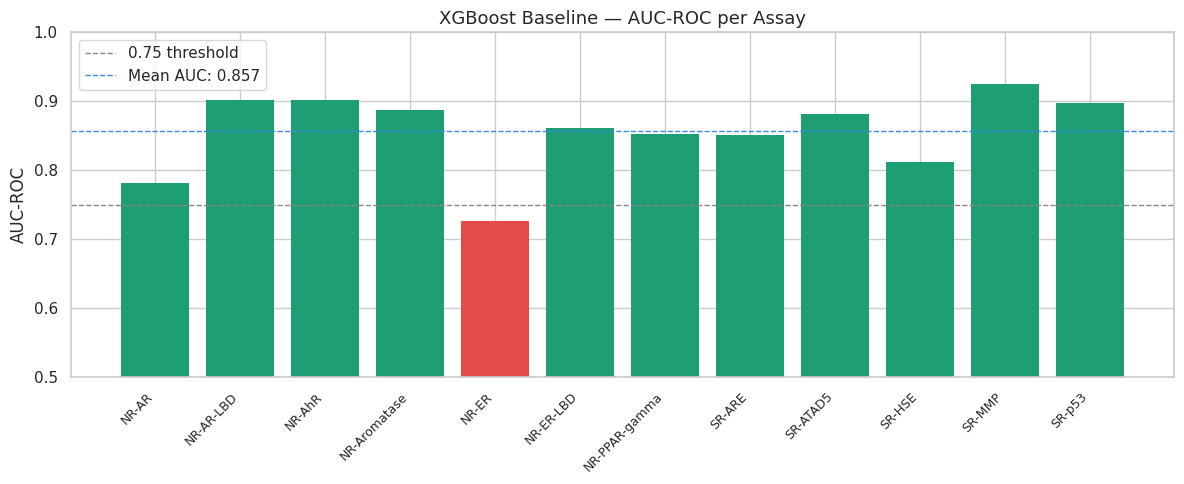

In [ ]:
#Cell — AUC bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#E24B4A' if v < 0.75 else '#1D9E75' for v in results_df['auc']]
bars = ax.bar(results_df['assay'], results_df['auc'], color=colors, edgecolor='none')
ax.axhline(0.75, color='#888780', linestyle='--', linewidth=1, label='0.75 threshold')
ax.axhline(results_df['auc'].mean(), color='#378ADD', linestyle='--',
           linewidth=1, label=f"Mean AUC: {results_df['auc'].mean():.3f}")
ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(results_df['assay'], rotation=45, ha='right', fontsize=9)
ax.set_title('XGBoost Baseline — AUC-ROC per Assay', fontsize=13, fontweight='500')
ax.set_ylabel('AUC-ROC')
ax.legend()
plt.tight_layout()
plt.savefig('/content/xgboost_auc.png', dpi=150)
plt.show()

Running SHAP on best assay: SR-MMP


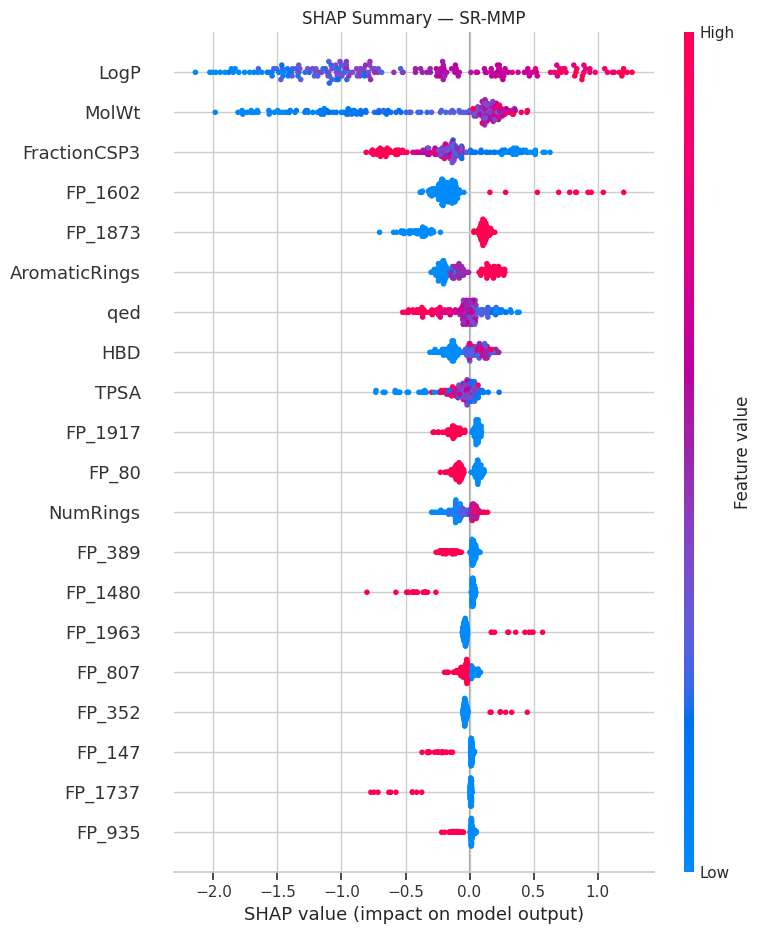

In [ ]:
#Cell — SHAP on best assay
best_assay = results_df.loc[results_df['auc'].idxmax(), 'assay']
print(f"Running SHAP on best assay: {best_assay}")

mask      = tox21_df[best_assay].notna()
X_task    = X[mask]
y_task    = tox21_df.loc[mask, best_assay].astype(int).values
X_train, X_test, y_train, y_test = train_test_split(
    X_task, y_task, test_size=0.2, random_state=42, stratify=y_task
)

explainer  = shap.TreeExplainer(models[best_assay])
shap_values = explainer.shap_values(X_test[:200])

# Feature names
fp_names   = [f'FP_{i}' for i in range(2048)]
feat_names = fp_names + desc_cols

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:200],
                  feature_names=feat_names,
                  max_display=20, show=False)
plt.title(f'SHAP Summary — {best_assay}', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

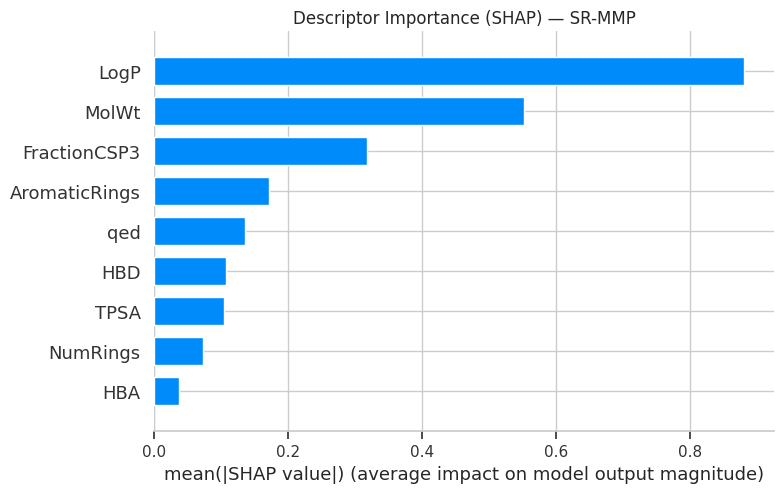

In [ ]:
#Cell — SHAP descriptor-only importance
# Isolate descriptor features only (last 9 columns)
desc_shap = shap_values[:, 2048:]

plt.figure(figsize=(8, 5))
shap.summary_plot(desc_shap, X_test[:200, 2048:],
                  feature_names=desc_cols,
                  plot_type='bar', show=False)
plt.title(f'Descriptor Importance (SHAP) — {best_assay}', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('/content/shap_descriptors.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Cell — Save models and results
import os, pickle
os.makedirs('/content/processed', exist_ok=True)

# Save all 12 models
with open('/content/processed/xgb_models.pkl', 'wb') as f:
    pickle.dump(models, f)

# Save results
results_df.to_csv('/content/processed/xgb_results.csv', index=False)

# Save feature config for nb03
config = {
    'assay_cols':  assay_cols,
    'desc_cols':   desc_cols,
    'n_fp_bits':   2048,
    'best_assay':  best_assay,
    'mean_auc':    round(float(results_df['auc'].mean()), 4)
}
import json
with open('/content/processed/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved:")
print("  /content/processed/xgb_models.pkl")
print("  /content/processed/xgb_results.csv")
print("  /content/processed/config.json")
print(f"\nBaseline mean AUC: {config['mean_auc']}")

Saved:
  /content/processed/xgb_models.pkl
  /content/processed/xgb_results.csv
  /content/processed/config.json

Baseline mean AUC: 0.8566


In [ ]:
import json, pickle

# Verify everything needed for nb03 exists
print("XGB models:", list(models.keys()))
print("Mean AUC:", config['mean_auc'])
print("Best assay:", config['best_assay'])

XGB models: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']
Mean AUC: 0.8566
Best assay: SR-MMP
